In [1]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]
Interesting_right =   [5, 33, 45, 49]
Interesting_left =   [4, 32, 44, 48]

Good_subjects =         [0, 2, 5, 9, 12, 14]
Ok_subjects =           [1, 3, 4, 6, 11, 13, 19]
Other_subjects = [i for i in range(20) if i not in Ok_subjects and i not in Good_subjects]

Subjects_dict = {"Good_subjects": Good_subjects, "Ok_subjects":Ok_subjects, "Other_subjects":Other_subjects}

data_folder="../Data/"

from BCI_Library import read_subject, plot_brain, train_models, extract_features_more_bands, select_regions_Cohen_effect_size, compute_welch
from BCI_Library import saveresults_pickle, select_rows, compute_welch, extract_features_from_spectra_more_bands,cohens_d_per_columm, select_rows


2026-05-22 09:59:04.935968: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 09:59:05.381199: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-22 09:59:07.985200: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
import pandas as pd

Rows = pd.DataFrame({
    "ROIs": [],
    "NROIs":[],
    "DataType": [],
    "freqs_band": [],  
    "subject": [],
    "Classifier": [],
    "Performance": [],
    "Features": [],
    "Comments": [],
    "Date": [],
    "Personalized_Freq_Range":[]
})

Rows.to_pickle("../Results/xxxxx.pkl")

# TEST

In [ ]:
# import os
# import pandas as pd

# folder1 = "../Results/BCI_Performances"


# for filename in os.listdir(folder1):
#     if filename.endswith(".pkl"):
#         file_path = os.path.join(folder1, filename)
        
#         # read dataframe
#         df = pd.read_pickle(file_path)
        
#         # rename column if present
#         if "Comments" in df.columns:
#             df = df.rename(columns={"aasas": "Region Selection"})
#             df["Comments"] = "-"

#         output_path = os.path.join(folder1, filename)
#         df.to_pickle(output_path)


In [2]:
import pandas as pd
undi = pd.read_pickle("../Results/RegionSelection/Selected_regions_Cohen_effect_size_EEG_among_5_folds_training_selected_freq_8_30.pkl")

In [22]:
undi.iloc[8]

Subject                                                                   8
ROIs_fold_1               (50, 51, 26, 27, 34, 21, 35, 15, 23, 13, 20, 7...
Effect_size_fold_1        (1.2426647226286591, 1.2147294428944513, 1.150...
ROIs_fold_2               (50, 26, 27, 20, 34, 51, 12, 13, 0, 35, 58, 7,...
Effect_size_fold_2        (1.1511806758409195, 1.119981038797324, 1.1106...
ROIs_fold_3               (50, 51, 27, 20, 34, 58, 13, 26, 15, 35, 7, 12...
Effect_size_fold_3        (1.1635501102020658, 1.1067660272754007, 1.091...
ROIs_fold_4               (50, 34, 51, 26, 27, 58, 15, 35, 12, 20, 7, 13...
Effect_size_fold_4        (1.1865815465536893, 1.1807131747598791, 1.142...
ROIs_fold_5               (50, 26, 51, 7, 27, 34, 21, 58, 35, 15, 12, 17...
Effect_size_fold_5        (1.223754008463993, 1.2042134318332753, 1.1483...
ROIs_All_trials           (50, 51, 26, 27, 34, 20, 35, 7, 58, 12, 15, 13...
Effect_size_All_trials    (1.1899035269077185, 1.1264729890430452, 1.093...
Name: 8, dty

In [3]:
undi.iloc[2,[1,3,5,7,9]].values

array([(32, 14, 50, 44, 33, 62, 48, 4, 47, 34, 35, 43, 27, 21, 46, 51, 26, 11, 42, 10, 6, 7, 54, 0, 24, 38, 15, 40, 20, 23, 65, 59, 58, 49, 39, 16, 5, 45, 8, 28, 36, 67, 37, 17, 56, 52, 1, 64, 30, 61, 31, 19, 3, 22, 29, 53, 66, 55, 13, 63, 25, 2, 9, 41, 12, 60, 57, 18),
       (32, 44, 33, 14, 50, 48, 62, 4, 47, 45, 34, 21, 42, 43, 35, 49, 46, 27, 7, 58, 15, 59, 26, 23, 5, 54, 36, 0, 51, 11, 10, 6, 40, 24, 38, 20, 65, 16, 8, 1, 67, 28, 39, 61, 17, 31, 3, 56, 64, 52, 30, 37, 66, 19, 22, 29, 53, 63, 13, 2, 60, 55, 12, 9, 25, 41, 57, 18),
       (44, 32, 14, 48, 50, 33, 62, 4, 34, 47, 27, 35, 43, 21, 23, 42, 58, 7, 26, 6, 46, 38, 24, 1, 5, 15, 0, 51, 54, 11, 45, 10, 40, 28, 20, 8, 16, 59, 36, 39, 65, 49, 17, 52, 67, 3, 31, 61, 56, 37, 53, 29, 64, 22, 19, 66, 30, 63, 12, 2, 55, 25, 13, 9, 60, 41, 57, 18),
       (32, 33, 62, 44, 14, 50, 48, 47, 4, 46, 34, 45, 0, 21, 35, 49, 67, 51, 54, 20, 11, 42, 26, 10, 27, 24, 6, 7, 38, 65, 40, 58, 28, 8, 43, 3, 5, 16, 56, 23, 52, 17, 36, 31, 39, 15, 61

array([(32, 14, 50, 44, 33, 62, 48, 4, 47, 34, 35, 43, 27, 21, 46, 51, 26, 11, 42, 10, 6, 7, 54, 0, 24, 38, 15, 40, 20, 23, 65, 59,  58, 49, 39, 16, 5, 45, 8, 28, 36, 67, 37, 17, 56, 52, 1, 64, 30, 61, 31, 19, 3, 22, 29, 53, 66, 55, 13, 63, 25, 2, 9, 41, 12, 60, 57, 18),
       (32, 44, 33, 14, 50, 48, 62, 4, 47, 45, 34, 21, 42, 43, 35, 49, 46, 27, 7, 58, 15, 59, 26, 23, 5, 54, 36, 0, 51, 11, 10, 6, 40, 24, 38, 20, 65, 16, 8, 1, 67, 28, 39, 61, 17, 31, 3, 56, 64, 52, 30, 37, 66, 19, 22, 29, 53, 63, 13, 2, 60, 55, 12, 9, 25, 41, 57, 18),
       (44, 32, 14, 48, 50, 33, 62, 4, 34, 47, 27, 35, 43, 21, 23, 42, 58, 7, 26, 6, 46, 38, 24, 1, 5, 15, 0, 51, 54, 11, 45, 10, 40, 28, 20, 8, 16, 59, 36, 39, 65, 49, 17, 52, 67, 3, 31, 61, 56, 37, 53, 29, 64, 22, 19, 66, 30, 63, 12, 2, 55, 25, 13, 9, 60, 41, 57, 18),
       (32, 33, 62, 44, 14, 50, 48, 47, 4, 46, 34, 45, 0, 21, 35, 49, 67, 51, 54, 20, 11, 42, 26, 10, 27, 24, 6, 7, 38, 65, 40, 58, 28, 8, 43, 3, 5, 16, 56, 23, 52, 17, 36, 31, 39, 15, 61, 59, 19, 22, 1, 53, 29, 2, 64, 66, 13, 37, 63, 30, 9, 57, 25, 12, 55, 60, 41, 18),
       (32, 33, 14, 44, 50, 47, 62, 48, 4, 46, 15, 34, 45, 35, 51, 27, 49, 7, 23, 6, 59, 43, 0, 21, 11, 10, 5, 58, 54, 24, 67, 42, 26, 17, 16, 38, 1, 40, 8, 36, 65, 28, 3, 39, 20, 52, 56, 37, 31, 19, 63, 64, 61, 12, 53, 22, 29, 30, 66, 2, 55, 9, 25, 13, 41, 60, 57, 18)],
      dtype=object)

In [24]:
a = [50, 51, 26, 27, 34, 21, 35, 15, 23, 13,
50, 26, 27, 20, 34, 51, 12, 13, 0, 35, 
50, 51, 27, 20, 34, 58, 13, 26, 15, 35,
50, 34, 51, 26, 27, 58, 15, 35, 12, 20,
50, 26, 51, 7, 27, 34, 21, 58, 35, 15, ]
set(a), len(set(a))

({0, 7, 12, 13, 15, 20, 21, 23, 26, 27, 34, 35, 50, 51, 58}, 15)

In [4]:
import numpy as np

x  = np.ones(shape=(10,10,10))

x[1:2,1:3,1:3].shape


(1, 2, 2)

In [1]:
import os
import re
import sys


def add_gitignore_to_reconstruction_folders(root_path):
    """
    Recursively searches for folders named:
    reconstrucion_plots_<number>
    and creates a .gitignore file inside them that ignores all content.
    """

    # Pattern: reconstruction_plots_<number>
    pattern = re.compile(r"^reconstruction_plots_\d+$")

    for dirpath, dirnames, filenames in os.walk(root_path):
        folder_name = os.path.basename(dirpath)

        if pattern.match(folder_name):
            gitignore_path = os.path.join(dirpath, ".gitignore")

            if not os.path.exists(gitignore_path):
                with open(gitignore_path, "w") as f:
                    f.write("*\n")

                print(f"Created .gitignore in: {dirpath}")
            else:
                print(f".gitignore already exists in: {dirpath}")


In [2]:
add_gitignore_to_reconstruction_folders("../_Deep_Learning/Models_trained")

.gitignore already exists in: ../_Deep_Learning/Models_trained/Subject_2/EEG/Autoencoders/2026-01-31-12_49_20_Autoencoder_1region_region_specific_cohen_global_First_Try/Split_5/Region_44/reconstruction_plots_5
.gitignore already exists in: ../_Deep_Learning/Models_trained/Subject_2/EEG/Autoencoders/2026-01-31-12_49_20_Autoencoder_1region_region_specific_cohen_global_First_Try/Split_5/Region_62/reconstruction_plots_5
.gitignore already exists in: ../_Deep_Learning/Models_trained/Subject_2/EEG/Autoencoders/2026-01-31-12_49_20_Autoencoder_1region_region_specific_cohen_global_First_Try/Split_5/Region_32/reconstruction_plots_5
.gitignore already exists in: ../_Deep_Learning/Models_trained/Subject_2/EEG/Autoencoders/2026-01-31-12_49_20_Autoencoder_1region_region_specific_cohen_global_First_Try/Split_5/Region_33/reconstruction_plots_5
.gitignore already exists in: ../_Deep_Learning/Models_trained/Subject_2/EEG/Autoencoders/2026-01-31-12_49_20_Autoencoder_1region_region_specific_cohen_global_F

In [21]:
from sklearn.model_selection import StratifiedKFold, train_test_split
import numpy as np
random_seed = 224 

X_Block_EEG = np.array([[j for i in range(15)] for j in range(30)])

y_Block_EEG = np.array([0]*15 + [1]*15)


X_val_EEG, X_test_EEG, y_val_EEG, y_test_EEG = train_test_split(
X_Block_EEG, y_Block_EEG, test_size=0.5,         
shuffle=True, stratify=y_Block_EEG,     # preserves label balance
random_state=random_seed)


X_Block_MEG =  np.array([[j for i in range(4)] for j in range(30)]) * -1

X_val_MEG, X_test_MEG, y_val_MEG, y_test_MEG = train_test_split(
X_Block_MEG, y_Block_EEG, test_size=0.5,         
shuffle=True, stratify=y_Block_EEG,     # preserves label balance
random_state=random_seed)


In [24]:
X_val_EEG

array([[ 8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8],
       [ 9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9],
       [29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29],
       [24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24],
       [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12],
       [23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23],
       [18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18],
       [22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22],
       [ 2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15],
       [ 6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6],
       [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
       [17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17],
       [28, 28, 28, 28, 28, 28, 28

In [26]:
1+False

1

In [23]:
X_test_MEG

array([[ -5,  -5,  -5,  -5],
       [-11, -11, -11, -11],
       [-27, -27, -27, -27],
       [-16, -16, -16, -16],
       [-20, -20, -20, -20],
       [-21, -21, -21, -21],
       [-25, -25, -25, -25],
       [ -4,  -4,  -4,  -4],
       [-14, -14, -14, -14],
       [-10, -10, -10, -10],
       [ -7,  -7,  -7,  -7],
       [-26, -26, -26, -26],
       [-19, -19, -19, -19],
       [ -3,  -3,  -3,  -3],
       [-13, -13, -13, -13]])

# IMPORTANT - Classify all 5 second with DL



In [2]:
from numpy.lib.stride_tricks import sliding_window_view
import numpy as np


def extract_windows(x, win_len=128, shift=62):
    """ OK, verified (see Test.ipynb -> Function extract window check)"""
    # x shape: (192, 68, 748) 
    # 192 trials, 68 ROIs, 748 time points
    # 128 + 62*(11-1)  = 748

    windows = sliding_window_view(x, window_shape=win_len, axis=-1)
    # windows shape: (192, 68, 748 - win_len + 1, win_len)

    # apply hop/shift
    windows = windows[..., ::shift, :]

    return windows


def windowize(X,Y, win_len=128, shift=62):
    """
    Function to extract windows from X and replicate labels Y accordingly 
    to assign the same label to all windows extracted from a single trace (trial)
    
    X: (n_traces, n_timepoints)
    Y: (n_traces,) (-68,-67,...,-1,1,2,...,68) sign based on Rest/MI, absolute value is region index
    win_len: timepoints of extracted windows
    shift: shift between windows (if shift < win_len, windows will overlap, desiderable for data augmentation)
    """

    X_windowed = extract_windows(X, win_len, shift)
    Y_windowed = np.repeat(Y[:, None], X_windowed.shape[1], axis=1)
    # X_windowed.shape, Y_windowed.shape
    # (n_traces, n_windows_per_trace, win_len), (n_traces, n_windows_per_trace)

    X_windowed_reshaped = X_windowed.reshape(-1, X_windowed.shape[-1])
    Y_windowed_reshaped = Y_windowed.reshape(-1,)
    
    # X_windowed_reshaped.shape, Y_windowed_reshaped.shape
    # (n_traces*n_windows_per_trace, win_len), (n_traces*n_windows_per_trace,)

    return X_windowed_reshaped, Y_windowed_reshaped

In [3]:
data_folder="../Data/"


from BCI_Library import read_subject
data_2_MI_EEG = read_subject(data_folder, "EEG", "MI", 18, verbose=False)
data_2_MI_EEG.shape

2026-05-22 18:00:58.012836: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 18:00:58.067545: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-22 18:00:59.234817: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


(87, 68, 1750)

In [4]:
start = 3           # seconds where to start to extract windows
sampling_hz = 250;  start = start*sampling_hz
input_shape = 256   # length of each window
shift = 256          # points to shift for next window in data
num_windows = 3     # how many windows to extract from each trial
end = start + (num_windows-1)*shift + input_shape  # seconds where to end to extract windows (1500 == 6 seconds)


x_val = data_2_MI_EEG[0:5, 34, start:end]

print(x_val.shape)

x_val = x_val.reshape(-1, x_val.shape[-1])

print(x_val.shape)

y_val = np.array([0,1,0,1,0])

(5, 768)
(5, 768)


In [5]:
x_val_windowed, y_val_windowed = windowize(x_val, y_val, win_len=input_shape, shift=256)

In [6]:
x_val_windowed.shape

(15, 256)

In [7]:
x_val_windowed_EGG_MEG = np.concatenate((x_val_windowed[:,:,np.newaxis], x_val_windowed[:,:,np.newaxis]), axis=-1)
x_val_windowed_EGG_MEG.shape

#Features_val = model.encoder(x_val_windowed_EGG_MEG)
# shape (15,16,1)
Features_test_1_regione = np.ones(shape=(15,16,1)) # (num_windows * num_trials, features, 1) 
Features_test_1_regione = Features_test_1_regione*np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])[:,None,None]

Features_test_1_regione_reshaped = Features_test_1_regione.reshape((Features_test_1_regione.shape[0]//num_windows,16*num_windows))

In [8]:
Features_test_1_regione_reshaped

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,
         2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.],
       [ 3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
         3.,  3.,  3.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,
         4.,  4.,  4.,  4.,  4.,  4.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,
         5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.],
       [ 6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
         6.,  6.,  6.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,
         7.,  7.,  7.,  7.,  7.,  7.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
         8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.],
       [ 9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,
         9.,  9.,  9., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10., 10., 10., 10

In [49]:
Features_test_1_regione[0]

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [39]:
Feat_test_regions_selected = np.empty((Features_test_1_regione.shape[0],0))
Feat_test_regions_selected.shape

(15, 0)

# compute welch on 3 s

In [1]:
data_folder="../Data/" #and libraries and funcitons
import sys
import numpy as np
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, train_test_split
import tqdm
import re 

sys.path.append(os.path.abspath("../Codes"))

sys.path.append(os.path.abspath("../_Deep_Learning"))

from Utils import split_create_windows, scale_newax
from Utils import freq_filter, windowize,  RegionWiseStandardizer

from BCI_Library import read_subject, saveresults_pickle, compute_welch
from BCI_Library import  train_single_model,select_regions_Cohen_effect_size, build_compiled_mlp

import tensorflow.keras as keras

def compute_power_spectra(data_2_MI, data_2_Rest, starttime=250, endtime=250):
    sfreq = 250
    miff = [8,12]
    maff = [12,30]

    WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                        kargs_welch={"fmin":miff[0], "fmax":maff[-1]},
                                        starttime=starttime, endtime=endtime,)

    return WMI, WRe


def selezione_cohen(WRe, WMI, train_idx, num_best_ROIs):
    training_index_Re = train_idx[np.where(train_idx<len(WRe))] 
    training_index_MI = train_idx[np.where(train_idx>=len(WRe))]-len(WRe)

    regions_selected, effect_size  = select_regions_Cohen_effect_size(wpsdMI=WMI[training_index_MI], 
                                                    wpsdRest=WRe[training_index_Re], 
                                                        important_regions=[], nbest_regions=num_best_ROIs)
    return regions_selected

2026-05-25 10:39:47.907085: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-25 10:39:47.982338: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-25 10:39:49.539413: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [16]:
oday = date.today()
sfreq = 250

seed = 224


random_seed=224

num_best_ROIs = 8


verbose = False



data_2_Rest_EEG = read_subject(data_folder, "EEG", "Baseline",2,verbose=verbose)
data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",2,verbose=verbose)
data_EEG = np.concatenate((data_2_Rest_EEG, data_2_MI_EEG), axis=0)
WMI_EEG_1s, WRe_EEG_1s = compute_power_spectra(data_2_MI_EEG,data_2_Rest_EEG, starttime=250)
WMI_EEG_3s, WRe_EEG_3s = compute_power_spectra(data_2_MI_EEG,data_2_Rest_EEG, starttime=750)

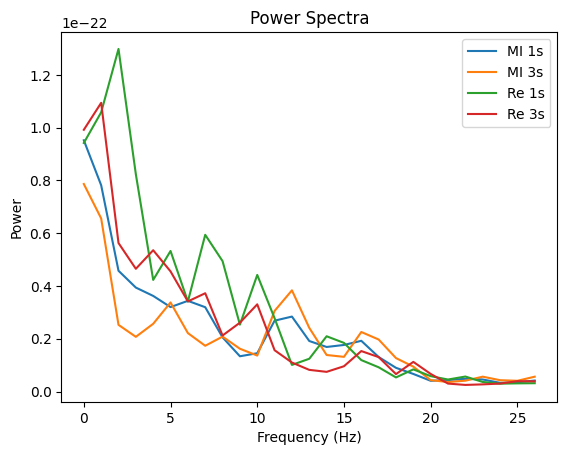

In [27]:
import matplotlib.pyplot as plt
region = 44
trial = 65
plt.plot(WMI_EEG_1s[trial,region,:], label="MI 1s")
plt.plot(WMI_EEG_3s[trial,region,:], label="MI 3s")
plt.plot(WRe_EEG_1s[trial,region,:], label="Re 1s")
plt.plot(WRe_EEG_3s[trial,region,:], label="Re 3s")


plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectra")
plt.legend()
plt.show()

In [21]:
import pandas as pd
pd.read_pickle("../Results/RegionSelection/Selected_regions_Cohen_effect_size_EEG_among_5_folds_training_selected_freq_8_30.pkl")
#pd.read_pickle("../Results/RegionSelection/Selected_regions_Cohen_effect_size_MEG_among_5_folds_training_selected_freq_8_30_starting_From_3s.pkl")

,Subject,ROIs_fold_1,Effect_size_fold_1,ROIs_fold_2,Effect_size_fold_2,ROIs_fold_3,Effect_size_fold_3,ROIs_fold_4,Effect_size_fold_4,ROIs_fold_5,Effect_size_fold_5,ROIs_All_trials,Effect_size_All_trials
0,0,"(32, 15, 14, 58, 17, 23, 46, 7, 51, 43, 59, 50...","(1.925180766116174, 1.8512339117302927, 1.8063...","(15, 14, 23, 17, 58, 50, 42, 7, 27, 32, 21, 6,...","(1.9855042008326862, 1.887252804576588, 1.8800...","(23, 14, 17, 15, 16, 26, 42, 21, 9, 58, 51, 20...","(1.9724908869986366, 1.9148067102125224, 1.893...","(23, 14, 15, 17, 58, 42, 51, 50, 27, 9, 34, 59...","(2.060550169875445, 1.9501869018266451, 1.9442...","(14, 15, 42, 58, 23, 22, 51, 50, 6, 26, 59, 17...","(2.1024617091401847, 2.0002766260626563, 1.900...","(14, 15, 23, 17, 58, 42, 50, 26, 9, 51, 59, 16...","(1.915491303887696, 1.8966578976792912, 1.8667..."
1,1,"(43, 67, 61, 1, 7, 59, 23, 19, 17, 27, 51, 31,...","(0.9796415132502583, 0.911317144533718, 0.8720...","(1, 61, 67, 19, 31, 43, 23, 59, 17, 51, 7, 9, ...","(1.1109152864726184, 0.991464849864428, 0.9875...","(67, 43, 59, 1, 61, 7, 23, 19, 51, 31, 42, 17,...","(0.9537219193924903, 0.9518340918565439, 0.914...","(67, 59, 61, 1, 43, 23, 51, 17, 19, 7, 31, 20,...","(0.9735480659561886, 0.9468104474154913, 0.922...","(23, 59, 7, 67, 61, 51, 43, 1, 31, 19, 17, 30,...","(0.9946209911786413, 0.9736117286324565, 0.962...","(67, 61, 1, 43, 59, 23, 7, 19, 51, 31, 17, 42,...","(0.9445296643407762, 0.9191849012987512, 0.913..."
2,2,"(32, 14, 50, 33, 44, 62, 48, 4, 47, 46, 23, 21...","(1.892931129191962, 1.8603873661360446, 1.8391...","(32, 44, 33, 50, 14, 48, 62, 4, 47, 34, 45, 46...","(1.8782430469487608, 1.8154416491640237, 1.799...","(32, 44, 14, 33, 50, 48, 62, 47, 4, 46, 45, 34...","(1.9025455201545085, 1.7959920742669926, 1.771...","(32, 14, 44, 33, 50, 62, 48, 4, 47, 34, 51, 35...","(2.0483249100717646, 1.9460662046308128, 1.903...","(32, 44, 33, 14, 62, 50, 48, 47, 4, 46, 34, 35...","(2.026797317681936, 1.8577718402257846, 1.8401...","(32, 44, 14, 33, 50, 62, 48, 4, 47, 34, 46, 35...","(1.9412558098516424, 1.8107556731989525, 1.801..."
3,3,"(7, 22, 23, 15, 51, 32, 33, 48, 50, 6, 59, 45,...","(1.3346329528477028, 1.198792893591348, 1.0441...","(7, 22, 51, 15, 23, 48, 50, 43, 32, 6, 14, 45,...","(1.3645038819448083, 1.1007786787054414, 0.810...","(22, 7, 51, 23, 15, 59, 48, 43, 32, 50, 14, 45...","(1.2368950700244252, 1.1914547421781156, 0.797...","(7, 22, 48, 23, 15, 32, 51, 50, 45, 20, 33, 59...","(1.1659276543019004, 1.152687374644075, 0.7892...","(7, 22, 23, 15, 32, 51, 48, 33, 56, 44, 8, 43,...","(1.164368767716693, 1.1342272415491401, 0.8657...","(7, 22, 23, 15, 51, 48, 32, 50, 43, 6, 33, 59,...","(1.2433947579623705, 1.1649432198005738, 0.847..."
4,4,"(16, 30, 12, 48, 3, 55, 63, 42, 4, 46, 26, 2, ...","(0.9503105145816323, 0.9069393650049947, 0.833...","(30, 12, 16, 48, 3, 4, 32, 2, 34, 55, 44, 31, ...","(1.0118811132257524, 0.9910971565849318, 0.949...","(30, 16, 12, 48, 4, 3, 34, 10, 2, 55, 18, 26, ...","(0.9513151753109704, 0.944557295544743, 0.8762...","(30, 16, 12, 48, 3, 4, 10, 34, 44, 32, 26, 25,...","(1.0859348634464185, 1.0341299664531685, 0.968...","(30, 12, 16, 48, 3, 2, 4, 34, 18, 55, 26, 44, ...","(1.1169568400114105, 1.0461808516917994, 1.034...","(30, 16, 12, 48, 3, 4, 34, 2, 55, 32, 10, 63, ...","(1.0115241411497549, 0.9663343672852897, 0.928..."
5,5,"(4, 17, 20, 47, 22, 46, 43, 42, 23, 58, 63, 62...","(1.654310567115808, 1.4604812690871525, 1.3831...","(4, 17, 58, 20, 14, 63, 47, 15, 46, 22, 23, 43...","(1.7586773116447374, 1.6788297023363552, 1.317...","(4, 17, 62, 20, 47, 23, 58, 46, 14, 43, 63, 22...","(1.7936984361018915, 1.4670159311927407, 1.321...","(4, 17, 63, 20, 23, 22, 46, 47, 16, 58, 62, 42...","(1.7523967949275732, 1.6199926337658899, 1.412...","(4, 17, 46, 63, 22, 20, 47, 23, 58, 14, 12, 62...","(1.760508789431928, 1.505384007918411, 1.23251...","(4, 17, 20, 47, 22, 46, 58, 23, 63, 62, 43, 14...","(1.7433088720094458, 1.544046557705569, 1.2761..."
6,6,"(44, 48, 4, 62, 0, 32, 1

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import plot_brain, read_ranks_subect
from matplotlib.colors import LinearSegmentedColormap
import os
import mne
#mne.viz.set_3d_backend('pyvistaqt')  # or 'pyvistaqt'
mne.viz.set_3d_backend('notebook')
# os.environ["SUBJECTS_DIR"] = subjects_dir
# print("SUBJECTS_DIR set to:", subjects_dir)
imgsize = 2400
colors = {"EEG":"green","MEG":"red"}
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]


N_best_ROIs = 8

for DataType in ["EEG","MEG"]: #["EEG","MEG"]:

    cmap = LinearSegmentedColormap.from_list("wt", ["white",colors[DataType]])
    savename = f"Brain_{DataType}_NROIs_{N_best_ROIs}_Cohen_alldata_nofold.png"

    how_many_times = {}
    for regione in range(68):
        how_many_times[regione] = 0
    num_subj_at_least_1_right, num_subj_at_least_1_left = (0,0)
    for subject in range(20):
        ranks_subject = read_ranks_subect("../Results/RegionSelection/" \
        f"Selected_regions_Cohen_effect_size_{DataType}_among_5_folds_training_selected_freq_8_30_starting_From_3s.pkl", subject, read_all_trials=True)[0]

        at_least_1_left, at_least_1_right = (0,0)
        for migiori_regioni in range(N_best_ROIs):
            regione_ora = ranks_subject[migiori_regioni]
            how_many_times[regione_ora] +=  1 
            # controllo se nel soggetto ha almeno 1 regione tra quelle importanti di destra o sinistra
            if regione_ora in Interesting_regions_left:
                at_least_1_left = 1
                #print(subject, regione_ora)
            if regione_ora in Interesting_regions_right:
                at_least_1_right = 1

        num_subj_at_least_1_right += at_least_1_right
        num_subj_at_least_1_left += at_least_1_left

    #cmap = LinearSegmentedColormap.from_list("wt", ["white",(160/255, 134/255, 44/255, 1)])
    #how_many_times = {i:1 if i in [4,5, 32,33, 44,45, 48,49] else 0 for i in range(68)} 
    savename=f"Brain_{DataType}.png"
            
    crs = [cmap(_/max(how_many_times.values())) for _ in how_many_times.values()]

    vvs = ['lateral','medial','rostral','caudal','dorsal']
    my_brain=plot_brain([int(_) for _ in how_many_times.keys()],
                        brain_object_dict={"title":f"{DataType}_NROIs{N_best_ROIs}","hemi": "both", "views":["dorsal"],"size":(imgsize, imgsize)}, colors=crs,
                        showbrainplot=False,
                        )
    # plotter = my_brain._renderer.plotter
    # plotter.add_text(
    #     f" Most selected region \n is selected in\n {max(how_many_times.values())} subjects\n on 20 subjects total",
    #     position="upper_left",
    #     font_size=10,
    #     color="black",
    # )

    savepathIMG = ""#"../Images/Paper/Brain/Region_selection_criteria/"
    my_brain.save_image(savepathIMG+savename)

    print(f"\n{DataType}: Most selected region is selected in {max(how_many_times.values())} subjects on 20 subjects total")
    print(f"Num of subject with at least 1 region in left important: {num_subj_at_least_1_left} right important: {num_subj_at_least_1_right}\n\n")

Reading labels from parcellation...
   read 35 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot

EEG: Most selected region is selected in 11 subjects on 20 subjects total
Num of subject with at least 1 region in left important: 14 right important: 10


Reading labels from parcellation...
   read 35 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot

MEG: Most selected region is selected in 10 subjects on 20 subjects total
Num of subject with at least 1 region in left important: 13 right important: 8


